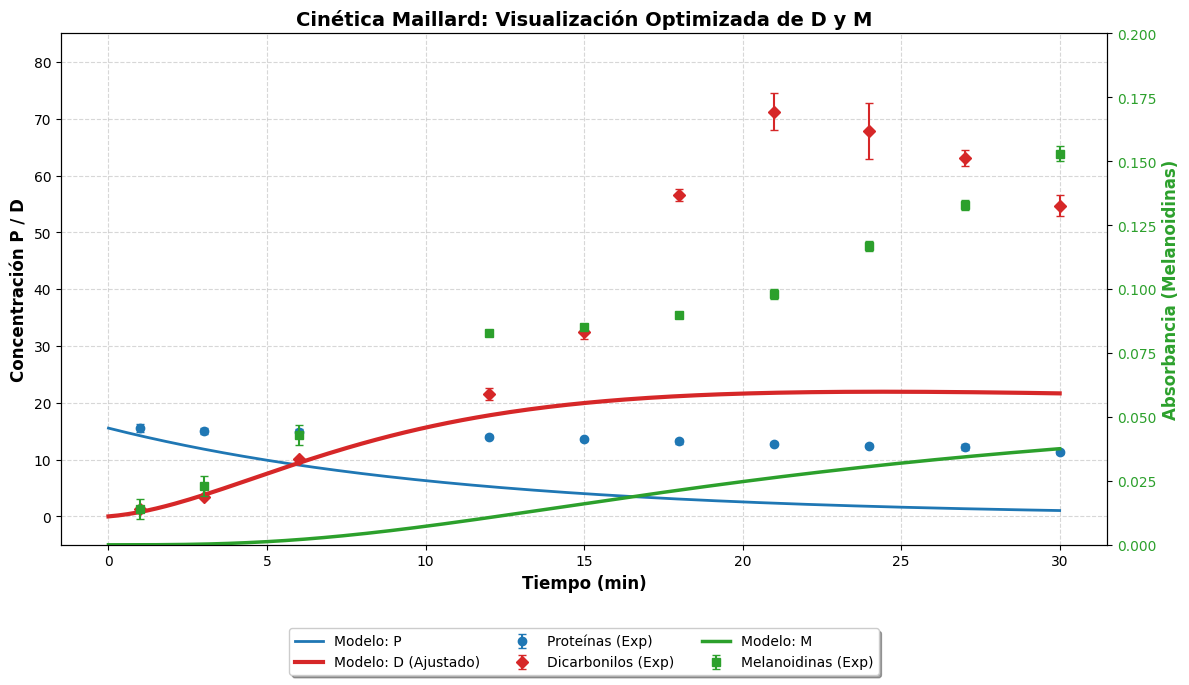

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. SOLVER RK4 DIFERENCIABLE
# =========================================
def rk4_solver(func, y0, t):
    y = [y0]
    curr_y = y0
    for i in range(len(t) - 1):
        h = t[i+1] - t[i]
        k1 = func(t[i], curr_y)
        k2 = func(t[i] + h/2, curr_y + h*k1/2)
        k3 = func(t[i] + h/2, curr_y + h*k2/2)
        k4 = func(t[i] + h, curr_y + h*k3)
        curr_y = curr_y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        y.append(curr_y)
    return torch.stack(y)

# =========================================
# 2. DATOS EXPERIMENTALES (200 °C)
# =========================================
t_exp = torch.tensor([1., 3., 6., 12., 15., 18., 21., 24., 27., 30.])

D_exp = torch.tensor([1.29, 3.39, 10.09, 21.49, 32.46, 56.54, 71.24, 67.79, 63.0, 54.7])
D_err = torch.tensor([0.06, 0.03, 0.13, 1.03, 1.16, 1.06, 3.27, 4.95, 1.41, 1.82])

M_exp = torch.tensor([0.014, 0.023, 0.043, 0.083, 0.085, 0.09, 0.098, 0.117, 0.133, 0.153])
M_err = torch.tensor([0.004, 0.004, 0.004, 0.001, 0.001, 0.001, 0.002, 0.002, 0.002, 0.003])

P_exp = torch.tensor([15.54, 15.04, 14.86, 14.06, 13.59, 13.24, 12.76, 12.43, 12.19, 11.32])
P_err = torch.tensor([0.72, 0.45, 0.47, 0.26, 0.27, 0.47, 0.27, 0.27, 0.47, 0.27])

P_scale, D_scale, M_scale = P_exp.max(), D_exp.max(), M_exp.max()
P_exp_n, D_exp_n, M_exp_n = P_exp/P_scale, D_exp/D_scale, M_exp/M_scale

# =========================================
# 3. MODELO DE RED NEURONAL ODE
# =========================================
class MaillardODE(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_kp = nn.Parameter(torch.tensor(-1.5))
        self.log_k1 = nn.Parameter(torch.tensor(-2.5))
        self.log_k2 = nn.Parameter(torch.tensor(-1.0))
        self.log_kd = nn.Parameter(torch.tensor(-1.8))

    def forward(self, t, y):
        P, A, S, D, M = y
        kp, k1, k2, kd = torch.exp(self.log_kp), torch.exp(self.log_k1), \
                         torch.exp(self.log_k2), torch.exp(self.log_kd)
        dPdt = -kp * P
        dAdt = kp * P - k1 * A * S - k2 * A * D
        dSdt = -k1 * A * S
        dDdt = k1 * A * S - k2 * A * D - kd * D
        dMdt = k2 * A * D
        return torch.stack([dPdt, dAdt, dSdt, dDdt, dMdt])

# =========================================
# 4. ENTRENAMIENTO
# =========================================
model = MaillardODE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
t_train = torch.cat([torch.tensor([0.0]), t_exp])
y0 = torch.tensor([P_exp_n[0], 0.05, 1.0, 0.0, 0.0])

for epoch in range(1001):
    optimizer.zero_grad()
    sol = rk4_solver(model, y0, t_train)
    P_pred, D_pred, M_pred = sol[1:, 0], sol[1:, 3], sol[1:, 4]

    # Ponderación para que D suba y M se ajuste bien
    loss = torch.mean(((P_pred - P_exp_n)/(P_err/P_scale))**2) + \
           10.0 * torch.mean(((D_pred - D_exp_n)/(D_err/D_scale))**2) + \
           2.0 * torch.mean(((M_pred - M_exp_n)/(M_err/M_scale))**2)

    loss.backward()
    optimizer.step()

# =========================================
# 5. VISUALIZACIÓN CON PROPORCIÓN OPTIMIZADA
# =========================================
with torch.no_grad():
    t_smooth = torch.linspace(0, 30, 200)
    sol_final = rk4_solver(model, y0, t_smooth).numpy()
    P_m = sol_final[:, 0] * P_scale.item()
    D_m = sol_final[:, 3] * D_scale.item()
    M_m = sol_final[:, 4] * M_scale.item()

plt.style.use('seaborn-v0_8-muted')
fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje Izquierdo: Proteínas y Dicarbonilos
ax1.errorbar(t_exp, P_exp, yerr=P_err, fmt='o', color='#1f77b4', label='Proteínas (Exp)', capsize=3)
ax1.errorbar(t_exp, D_exp, yerr=D_err, fmt='D', color='#d62728', label='Dicarbonilos (Exp)', capsize=3)
ax1.plot(t_smooth, P_m, color='#1f77b4', linewidth=2, label='Modelo: P')
ax1.plot(t_smooth, D_m, color='#d62728', linewidth=3, label='Modelo: D (Ajustado)')

ax1.set_xlabel("Tiempo (min)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Concentración P / D", fontsize=12, fontweight='bold')
ax1.set_ylim(-5, 85) # Espacio para que la curva D respire
ax1.grid(True, linestyle='--', alpha=0.5)

# Eje Derecho: Melanoidinas (Aumento de proporción visual)
ax2 = ax1.twinx()
ax2.errorbar(t_exp, M_exp, yerr=M_err, fmt='s', color='#2ca02c', label='Melanoidinas (Exp)', capsize=3)
ax2.plot(t_smooth, M_m, color='#2ca02c', linewidth=2.5, label='Modelo: M')

# AJUSTE CRÍTICO: Definimos el límite para que la curva M ocupe más espacio visual
ax2.set_ylabel("Absorbancia (Melanoidinas)", color='#2ca02c', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 0.20) # Ajustado para que 0.15 no quede en el fondo
ax2.tick_params(axis='y', labelcolor='#2ca02c')

# Leyenda
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, shadow=True)

plt.title("Cinética Maillard: Visualización Optimizada de D y M", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Iniciando entrenamiento...
Epoch 0 | Loss: 12008.1113
Epoch 500 | Loss: 8740.2432
Epoch 1000 | Loss: 8178.0869
Epoch 1500 | Loss: 8031.3848

--- Parámetros Cinéticos Aprendidos ---
kp (Degradación P): 0.090209
k1 (Formación D):   0.124081
k2 (Formación M):   0.143968
kd (Degradación D): 0.003357


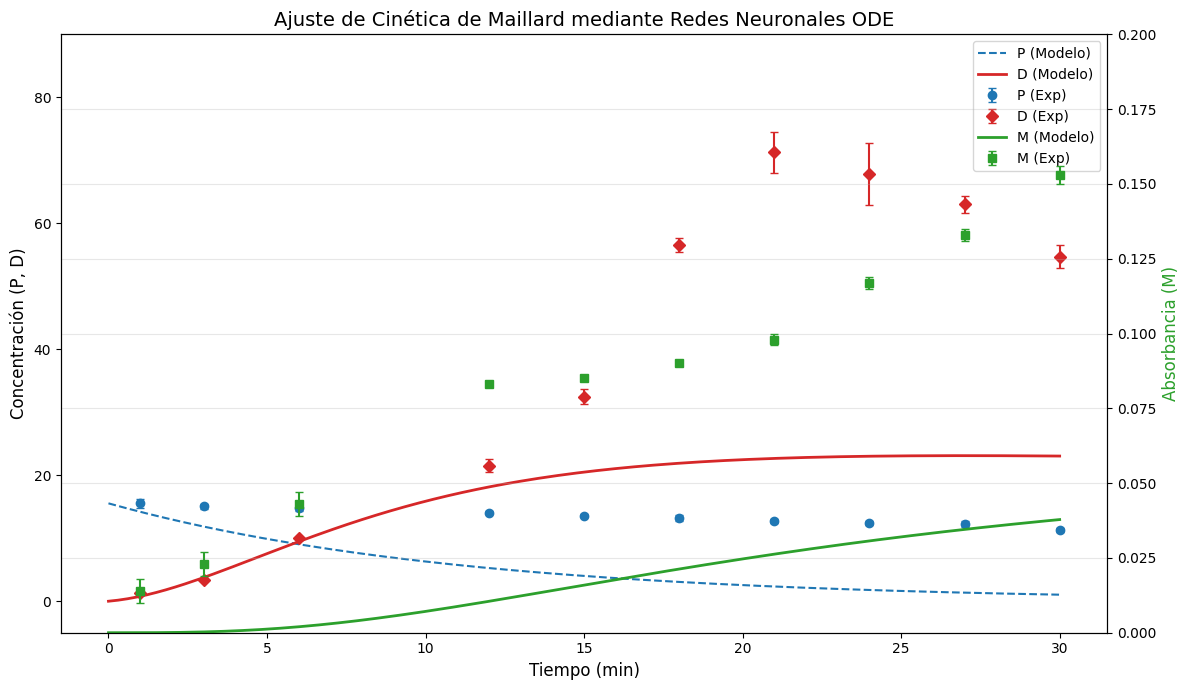

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. SOLVER RK4 DIFERENCIABLE
# =========================================
# Este solver permite que el gradiente fluya a través de la integración
def rk4_solver(func, y0, t):
    y = [y0]
    curr_y = y0
    for i in range(len(t) - 1):
        h = t[i+1] - t[i]
        k1 = func(t[i], curr_y)
        k2 = func(t[i] + h/2, curr_y + h*k1/2)
        k3 = func(t[i] + h/2, curr_y + h*k2/2)
        k4 = func(t[i] + h, curr_y + h*k3)
        curr_y = curr_y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        y.append(curr_y)
    return torch.stack(y)

# =========================================
# 2. DATOS EXPERIMENTALES (200 °C)
# =========================================
t_exp = torch.tensor([1., 3., 6., 12., 15., 18., 21., 24., 27., 30.])

# Proteínas (P), Dicarbonilos (D) y Melanoidinas (M)
D_exp = torch.tensor([1.29, 3.39, 10.09, 21.49, 32.46, 56.54, 71.24, 67.79, 63.0, 54.7])
D_err = torch.tensor([0.06, 0.03, 0.13, 1.03, 1.16, 1.06, 3.27, 4.95, 1.41, 1.82])

M_exp = torch.tensor([0.014, 0.023, 0.043, 0.083, 0.085, 0.09, 0.098, 0.117, 0.133, 0.153])
M_err = torch.tensor([0.004, 0.004, 0.004, 0.001, 0.001, 0.001, 0.002, 0.002, 0.002, 0.003])

P_exp = torch.tensor([15.54, 15.04, 14.86, 14.06, 13.59, 13.24, 12.76, 12.43, 12.19, 11.32])
P_err = torch.tensor([0.72, 0.45, 0.47, 0.26, 0.27, 0.47, 0.27, 0.27, 0.47, 0.27])

# Normalización para facilitar el entrenamiento del gradiente
P_scale, D_scale, M_scale = P_exp.max(), D_exp.max(), M_exp.max()
P_exp_n, D_exp_n, M_exp_n = P_exp/P_scale, D_exp/D_scale, M_exp/M_scale

# =========================================
# 3. MODELO DE RED NEURONAL ODE (UDE)
# =========================================
class MaillardODE(nn.Module):
    def __init__(self):
        super().__init__()
        # Inicializamos en escala logarítmica para asegurar que k > 0
        self.log_kp = nn.Parameter(torch.tensor(-1.5))
        self.log_k1 = nn.Parameter(torch.tensor(-2.5))
        self.log_k2 = nn.Parameter(torch.tensor(-1.0))
        self.log_kd = nn.Parameter(torch.tensor(-1.8))

    def forward(self, t, y):
        P, A, S, D, M = y
        kp, k1, k2, kd = torch.exp(self.log_kp), torch.exp(self.log_k1), \
                         torch.exp(self.log_k2), torch.exp(self.log_kd)

        # Sistema de Ecuaciones Diferenciales
        dPdt = -kp * P
        dAdt = kp * P - k1 * A * S - k2 * A * D
        dSdt = -k1 * A * S
        dDdt = k1 * A * S - k2 * A * D - kd * D
        dMdt = k2 * A * D

        return torch.stack([dPdt, dAdt, dSdt, dDdt, dMdt])

# =========================================
# 4. ENTRENAMIENTO
# =========================================
model = MaillardODE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
t_train = torch.cat([torch.tensor([0.0]), t_exp])

# Condiciones iniciales [P, A, S, D, M]
y0 = torch.tensor([P_exp_n[0], 0.05, 1.0, 0.0, 0.0])

print("Iniciando entrenamiento...")
for epoch in range(1501):
    optimizer.zero_grad()
    sol = rk4_solver(model, y0, t_train)

    # Extraemos solo los estados que tienen datos experimentales
    P_pred, D_pred, M_pred = sol[1:, 0], sol[1:, 3], sol[1:, 4]

    # Función de pérdida ponderada por el error experimental
    loss = torch.mean(((P_pred - P_exp_n)/(P_err/P_scale))**2) + \
           10.0 * torch.mean(((D_pred - D_exp_n)/(D_err/D_scale))**2) + \
           2.0 * torch.mean(((M_pred - M_exp_n)/(M_err/M_scale))**2)

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# =========================================
# 5. RESULTADOS Y VISUALIZACIÓN
# =========================================
with torch.no_grad():
    t_smooth = torch.linspace(0, 30, 200)
    sol_final = rk4_solver(model, y0, t_smooth).numpy()

    # Desnormalización
    P_m = sol_final[:, 0] * P_scale.item()
    D_m = sol_final[:, 3] * D_scale.item()
    M_m = sol_final[:, 4] * M_scale.item()

    # Mostrar constantes aprendidas
    print("\n--- Parámetros Cinéticos Aprendidos ---")
    print(f"kp (Degradación P): {torch.exp(model.log_kp).item():.6f}")
    print(f"k1 (Formación D):   {torch.exp(model.log_k1).item():.6f}")
    print(f"k2 (Formación M):   {torch.exp(model.log_k2).item():.6f}")
    print(f"kd (Degradación D): {torch.exp(model.log_kd).item():.6f}")

# Plotting
plt.style.use('seaborn-v0_8-muted')
fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje Izquierdo: P y D
ax1.errorbar(t_exp, P_exp, yerr=P_err, fmt='o', color='#1f77b4', label='P (Exp)', capsize=3)
ax1.errorbar(t_exp, D_exp, yerr=D_err, fmt='D', color='#d62728', label='D (Exp)', capsize=3)
ax1.plot(t_smooth, P_m, color='#1f77b4', linestyle='--', label='P (Modelo)')
ax1.plot(t_smooth, D_m, color='#d62728', linewidth=2, label='D (Modelo)')
ax1.set_xlabel("Tiempo (min)", fontsize=12)
ax1.set_ylabel("Concentración (P, D)", fontsize=12)
ax1.set_ylim(-5, 90)

# Eje Derecho: M
ax2 = ax1.twinx()
ax2.errorbar(t_exp, M_exp, yerr=M_err, fmt='s', color='#2ca02c', label='M (Exp)', capsize=3)
ax2.plot(t_smooth, M_m, color='#2ca02c', linewidth=2, label='M (Modelo)')
ax2.set_ylabel("Absorbancia (M)", color='#2ca02c', fontsize=12)
ax2.set_ylim(0, 0.20)

plt.title("Ajuste de Cinética de Maillard mediante Redes Neuronales ODE", fontsize=14)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Entrenando modelo para 220 °C...
Época 0 | Loss: 15226.3613
Época 500 | Loss: 8083.5654
Época 1000 | Loss: 7491.5664
Época 1500 | Loss: 7350.8247
Época 2000 | Loss: 7293.5649


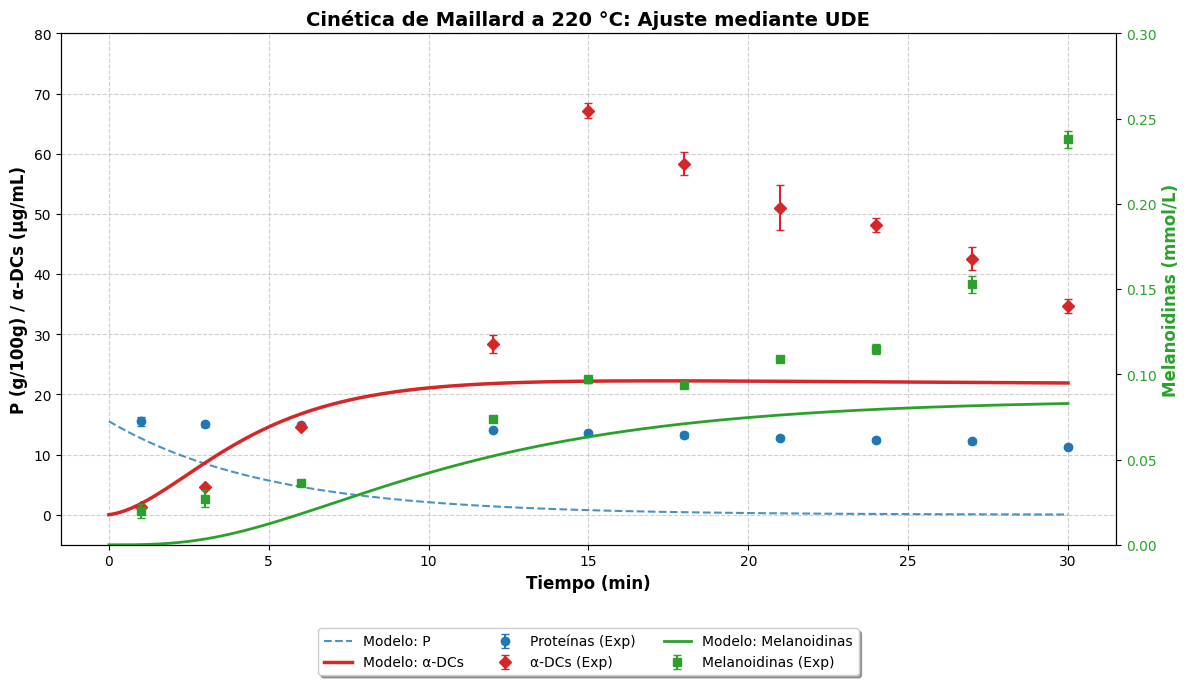


--- Constantes Cinéticas Aprendidas (220 °C) ---
kp: 0.20113
k1: 0.17704
k2: 0.29446
kd: 0.00115


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. SOLVER RK4 DIFERENCIABLE
# =========================================
def rk4_solver(func, y0, t):
    y = [y0]
    curr_y = y0
    for i in range(len(t) - 1):
        h = t[i+1] - t[i]
        k1 = func(t[i], curr_y)
        k2 = func(t[i] + h/2, curr_y + h*k1/2)
        k3 = func(t[i] + h/2, curr_y + h*k2/2)
        k4 = func(t[i] + h, curr_y + h*k3)
        curr_y = curr_y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        y.append(curr_y)
    return torch.stack(y)

# =========================================
# 2. DATOS EXPERIMENTALES (220 °C)
# =========================================
t_exp = torch.tensor([1., 3., 6., 12., 15., 18., 21., 24., 27., 30.])

# Datos: Dicarbonilos (D)
D_exp = torch.tensor([1.33, 4.58, 14.64, 28.41, 67.17, 58.38, 51.04, 48.09, 42.57, 34.73])
D_err = torch.tensor([0.07, 0.32, 0.25, 1.48, 1.21, 1.92, 3.74, 1.17, 1.93, 1.14])

# Datos: Melanoidinas (M)
M_exp = torch.tensor([0.02, 0.027, 0.036, 0.074, 0.097, 0.094, 0.109, 0.115, 0.153, 0.238])
M_err = torch.tensor([0.004, 0.005, 0.001, 0.001, 0.002, 0.002, 0.001, 0.003, 0.005, 0.005])

# Datos: Proteínas (P)
P_exp = torch.tensor([15.54, 15.04, 14.86, 14.06, 13.59, 13.24, 12.76, 12.43, 12.19, 11.32])
P_err = torch.tensor([0.72, 0.45, 0.47, 0.26, 0.27, 0.47, 0.27, 0.27, 0.47, 0.27])

# Escalamiento para el entrenamiento
P_scale, D_scale, M_scale = P_exp.max(), D_exp.max(), M_exp.max()
P_exp_n, D_exp_n, M_exp_n = P_exp/P_scale, D_exp/D_scale, M_exp/M_scale

# =========================================
# 3. MODELO DE RED NEURONAL ODE
# =========================================
class MaillardODE_220(nn.Module):
    def __init__(self):
        super().__init__()
        # Inicialización de parámetros (log-space)
        self.log_kp = nn.Parameter(torch.tensor(-1.2)) # Mayor que a 200°C por la T
        self.log_k1 = nn.Parameter(torch.tensor(-2.0))
        self.log_k2 = nn.Parameter(torch.tensor(-0.8))
        self.log_kd = nn.Parameter(torch.tensor(-1.5))

    def forward(self, t, y):
        P, A, S, D, M = y
        kp, k1, k2, kd = torch.exp(self.log_kp), torch.exp(self.log_k1), \
                         torch.exp(self.log_k2), torch.exp(self.log_kd)

        # Dinámica del sistema
        dPdt = -kp * P
        dAdt = kp * P - k1 * A * S - k2 * A * D
        dSdt = -k1 * A * S
        dDdt = k1 * A * S - k2 * A * D - kd * D
        dMdt = k2 * A * D
        return torch.stack([dPdt, dAdt, dSdt, dDdt, dMdt])

# =========================================
# 4. ENTRENAMIENTO
# =========================================
model = MaillardODE_220()
optimizer = torch.optim.Adam(model.parameters(), lr=0.008)
t_train = torch.cat([torch.tensor([0.0]), t_exp])

# Condiciones iniciales: [P, A, S, D, M]
# Aumentamos ligeramente la disponibilidad de azúcar inicial (S=1.2) para compensar la T
y0 = torch.tensor([P_exp_n[0], 0.05, 1.2, 0.0, 0.0])

print("Entrenando modelo para 220 °C...")
for epoch in range(2001):
    optimizer.zero_grad()
    sol = rk4_solver(model, y0, t_train)
    P_pred, D_pred, M_pred = sol[1:, 0], sol[1:, 3], sol[1:, 4]

    # Pérdida con pesos ajustados para la volatilidad de D a 220°C
    loss = torch.mean(((P_pred - P_exp_n)/(P_err/P_scale))**2) + \
           15.0 * torch.mean(((D_pred - D_exp_n)/(D_err/D_scale))**2) + \
           5.0 * torch.mean(((M_pred - M_exp_n)/(M_err/M_scale))**2)

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Época {epoch} | Loss: {loss.item():.4f}")

# =========================================
# 5. VISUALIZACIÓN
# =========================================
with torch.no_grad():
    t_smooth = torch.linspace(0, 30, 300)
    sol_final = rk4_solver(model, y0, t_smooth).numpy()
    P_m = sol_final[:, 0] * P_scale.item()
    D_m = sol_final[:, 3] * D_scale.item()
    M_m = sol_final[:, 4] * M_scale.item()

plt.style.use('seaborn-v0_8-muted')
fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje Izquierdo: Proteínas y Dicarbonilos
ax1.errorbar(t_exp, P_exp, yerr=P_err, fmt='o', color='#1f77b4', label='Proteínas (Exp)', capsize=3)
ax1.errorbar(t_exp, D_exp, yerr=D_err, fmt='D', color='#d62728', label='α-DCs (Exp)', capsize=3)
ax1.plot(t_smooth, P_m, color='#1f77b4', linestyle='--', alpha=0.8, label='Modelo: P')
ax1.plot(t_smooth, D_m, color='#d62728', linewidth=2.5, label='Modelo: α-DCs')

ax1.set_xlabel("Tiempo (min)", fontsize=12, fontweight='bold')
ax1.set_ylabel("P (g/100g) / α-DCs (μg/mL)", fontsize=12, fontweight='bold')
ax1.set_ylim(-5, 80)
ax1.grid(True, linestyle='--', alpha=0.6)

# Eje Derecho: Melanoidinas
ax2 = ax1.twinx()
ax2.errorbar(t_exp, M_exp, yerr=M_err, fmt='s', color='#2ca02c', label='Melanoidinas (Exp)', capsize=3)
ax2.plot(t_smooth, M_m, color='#2ca02c', linewidth=2, label='Modelo: Melanoidinas')

ax2.set_ylabel("Melanoidinas (mmol/L)", color='#2ca02c', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 0.30) # Rango ampliado para 220°C
ax2.tick_params(axis='y', labelcolor='#2ca02c')

# Consolidar leyendas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, shadow=True)

plt.title("Cinética de Maillard a 220 °C: Ajuste mediante UDE", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Imprimir las constantes calculadas por el ML
print("\n--- Constantes Cinéticas Aprendidas (220 °C) ---")
print(f"kp: {torch.exp(model.log_kp).item():.5f}")
print(f"k1: {torch.exp(model.log_k1).item():.5f}")
print(f"k2: {torch.exp(model.log_k2).item():.5f}")
print(f"kd: {torch.exp(model.log_kd).item():.5f}")

Entrenando modelo para 240 °C...
Época 0 | Loss: 37478.2461
Época 500 | Loss: 18766.6836
Época 1000 | Loss: 17646.0273
Época 1500 | Loss: 17378.7461
Época 2000 | Loss: 17272.7383
Época 2500 | Loss: 17219.4180


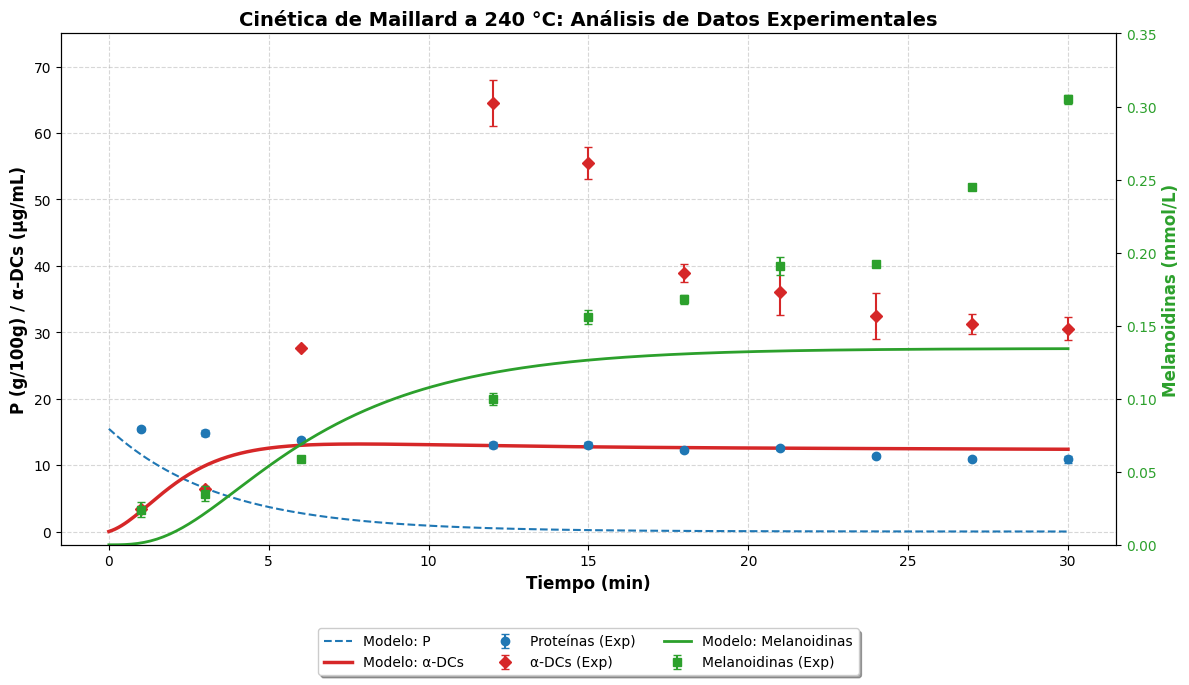


--- Constantes Cinéticas Aprendidas (240 °C) ---
kp (Degradación Proteína): 0.28653
k1 (Formación α-DCs):     0.18542
k2 (Formación Melanoid.): 0.90062
kd (Consumo α-DCs):       0.00122


In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. SOLVER RK4 DIFERENCIABLE
# =========================================
def rk4_solver(func, y0, t):
    y = [y0]
    curr_y = y0
    for i in range(len(t) - 1):
        h = t[i+1] - t[i]
        k1 = func(t[i], curr_y)
        k2 = func(t[i] + h/2, curr_y + h*k1/2)
        k3 = func(t[i] + h/2, curr_y + h*k2/2)
        k4 = func(t[i] + h, curr_y + h*k3)
        curr_y = curr_y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        y.append(curr_y)
    return torch.stack(y)

# =========================================
# 2. DATOS EXPERIMENTALES (240 °C)
# =========================================
t_exp = torch.tensor([1., 3., 6., 12., 15., 18., 21., 24., 27., 30.])

# α-DCs (μg/mL)
D_exp = torch.tensor([3.45, 6.41, 27.63, 64.54, 55.45, 38.91, 36.08, 32.43, 31.25, 30.56])
D_err = torch.tensor([0.32, 0.3, 0.29, 3.5, 2.41, 1.31, 3.52, 3.5, 1.47, 1.71])

# Melanoidinas (mmol/L)
M_exp = torch.tensor([0.024, 0.035, 0.059, 0.1, 0.156, 0.168, 0.191, 0.192, 0.245, 0.305])
M_err = torch.tensor([0.005, 0.005, 0.002, 0.004, 0.005, 0.003, 0.006, 0.001, 0.002, 0.003])

# Concentración de proteínas (g/100g)
P_exp = torch.tensor([15.47, 14.79, 13.79, 13.03, 12.98, 12.26, 12.62, 11.4, 10.9, 10.87])
P_err = torch.tensor([0.27, 0.48, 0.28, 0.47, 0.47, 0.28, 0.27, 0.27, 0.27, 0.54])

# Normalización para estabilidad numérica
P_scale, D_scale, M_scale = P_exp.max(), D_exp.max(), M_exp.max()
P_exp_n, D_exp_n, M_exp_n = P_exp/P_scale, D_exp/D_scale, M_exp/M_scale

# =========================================
# 3. MODELO DE RED NEURONAL ODE
# =========================================
class MaillardODE_240(nn.Module):
    def __init__(self):
        super().__init__()
        # Inicializamos con valores ligeramente más altos debido a la mayor T
        self.log_kp = nn.Parameter(torch.tensor(-1.0))
        self.log_k1 = nn.Parameter(torch.tensor(-1.8))
        self.log_k2 = nn.Parameter(torch.tensor(-0.5))
        self.log_kd = nn.Parameter(torch.tensor(-1.2))

    def forward(self, t, y):
        P, A, S, D, M = y
        kp, k1, k2, kd = torch.exp(self.log_kp), torch.exp(self.log_k1), \
                         torch.exp(self.log_k2), torch.exp(self.log_kd)

        # Sistema Cinético
        dPdt = -kp * P
        dAdt = kp * P - k1 * A * S - k2 * A * D
        dSdt = -k1 * A * S
        dDdt = k1 * A * S - k2 * A * D - kd * D
        dMdt = k2 * A * D
        return torch.stack([dPdt, dAdt, dSdt, dDdt, dMdt])

# =========================================
# 4. ENTRENAMIENTO
# =========================================
model = MaillardODE_240()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # LR ligeramente más alto
t_train = torch.cat([torch.tensor([0.0]), t_exp])

# Condiciones iniciales normalizadas
y0 = torch.tensor([P_exp_n[0], 0.08, 1.5, 0.0, 0.0])

print("Entrenando modelo para 240 °C...")
for epoch in range(2501):
    optimizer.zero_grad()
    sol = rk4_solver(model, y0, t_train)
    P_pred, D_pred, M_pred = sol[1:, 0], sol[1:, 3], sol[1:, 4]

    # Pérdida ponderada
    loss = torch.mean(((P_pred - P_exp_n)/(P_err/P_scale))**2) + \
           15.0 * torch.mean(((D_pred - D_exp_n)/(D_err/D_scale))**2) + \
           10.0 * torch.mean(((M_pred - M_exp_n)/(M_err/M_scale))**2)

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Época {epoch} | Loss: {loss.item():.4f}")

# =========================================
# 5. VISUALIZACIÓN
# =========================================
with torch.no_grad():
    t_smooth = torch.linspace(0, 30, 300)
    sol_final = rk4_solver(model, y0, t_smooth).numpy()
    P_m = sol_final[:, 0] * P_scale.item()
    D_m = sol_final[:, 3] * D_scale.item()
    M_m = sol_final[:, 4] * M_scale.item()

plt.style.use('seaborn-v0_8-muted')
fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje Principal (Proteínas y Dicarbonilos)
ax1.errorbar(t_exp, P_exp, yerr=P_err, fmt='o', color='#1f77b4', label='Proteínas (Exp)', capsize=3)
ax1.errorbar(t_exp, D_exp, yerr=D_err, fmt='D', color='#d62728', label='α-DCs (Exp)', capsize=3)
ax1.plot(t_smooth, P_m, color='#1f77b4', linestyle='--', label='Modelo: P')
ax1.plot(t_smooth, D_m, color='#d62728', linewidth=2.5, label='Modelo: α-DCs')

ax1.set_xlabel("Tiempo (min)", fontsize=12, fontweight='bold')
ax1.set_ylabel("P (g/100g) / α-DCs (μg/mL)", fontsize=12, fontweight='bold')
ax1.set_ylim(-2, 75)
ax1.grid(True, linestyle='--', alpha=0.5)

# Eje Secundario (Melanoidinas)
ax2 = ax1.twinx()
ax2.errorbar(t_exp, M_exp, yerr=M_err, fmt='s', color='#2ca02c', label='Melanoidinas (Exp)', capsize=3)
ax2.plot(t_smooth, M_m, color='#2ca02c', linewidth=2, label='Modelo: Melanoidinas')
ax2.set_ylabel("Melanoidinas (mmol/L)", color='#2ca02c', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 0.35)
ax2.tick_params(axis='y', labelcolor='#2ca02c')

# Leyenda unificada
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, shadow=True)

plt.title("Cinética de Maillard a 240 °C: Análisis de Datos Experimentales", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Parámetros finales
print("\n--- Constantes Cinéticas Aprendidas (240 °C) ---")
print(f"kp (Degradación Proteína): {torch.exp(model.log_kp).item():.5f}")
print(f"k1 (Formación α-DCs):     {torch.exp(model.log_k1).item():.5f}")
print(f"k2 (Formación Melanoid.): {torch.exp(model.log_k2).item():.5f}")
print(f"kd (Consumo α-DCs):       {torch.exp(model.log_kd).item():.5f}")